# TASK 21: Dynamics on networks

### Epidemic spreading on static networks: SI, SIS, SIR, SEIR in homogeneous and heterogeneous mean-field approximation

The objective of this project is to simulate the behavior of some well-known dynamical models, and possibly analyze their behavior (e.g., identify the critical epidemic threshold or the invasion threshold). The students are left free to follow the bibliographic references to understand what should be simulated and how, as well as to reproduce the main results and, if willing to do so, explore new directions.

It is required that these models are studied, computationally, across a variety of different synthetic topologies. Applications to real-world networks will be a plus.

In [1]:
import numpy as np
import networkx as nx
import random
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import matplotlib as mpl

## Functions

### Helper functions

In [2]:
# Dynamics on network
def epidemic_simulation(G, model="SIS", beta=0.3, mu=0.1, sigma=0.2, initial_infected=5, T=100):
    
    N = G.number_of_nodes()
    nodes = list(G.nodes())

    # states
    S, I, R, E = 0, 1, 2, 3
    
    state = {node: S for node in nodes}
    
    infected_nodes = random.sample(nodes, initial_infected)
    
    for node in infected_nodes:
        state[node] = I

    S_t = []
    I_t = []
    R_t = []
    E_t = []

    for t in range(T):
        
        new_state = state.copy()

        for node in nodes:

            if state[node] == I:

                # Infect neighbors 
                for neighbor in G.neighbors(node):
                    if state[neighbor] == S:
                        if random.random() < beta:
                            
                            if model == "SEIR":
                                new_state[neighbor] = E
                            else:
                                new_state[neighbor] = I

                # Recovery
                if model in ["SIS", "SIR", "SEIR"]:
                    if random.random() < mu:
                        
                        if model == "SIS":
                            new_state[node] = S
                        else:
                            new_state[node] = R

            elif state[node] == E:
                if random.random() < sigma:
                    new_state[node] = I

        state = new_state

        S_count = sum(1 for s in state.values() if s == S)
        I_count = sum(1 for s in state.values() if s == I)
        R_count = sum(1 for s in state.values() if s == R)
        E_count = sum(1 for s in state.values() if s == E)

        S_t.append(S_count / N)
        I_t.append(I_count / N)
        R_t.append(R_count / N)
        E_t.append(E_count / N)

    return np.array(S_t), np.array(I_t), np.array(R_t), np.array(E_t)

In [3]:
# Mean field approximation
def binomial_chain(model="SIS", beta=0.3, mu=0.1, sigma=0.2, k=10, T=100, rho0=0.01):

    S = np.zeros(T)
    I = np.zeros(T)
    R = np.zeros(T)
    E = np.zeros(T)

    S[0] = 1 - rho0
    I[0] = rho0

    for t in range(T-1):

        infection_prob = 1 - (1 - beta * I[t])**k

        if model == "SI":

            S[t+1] = S[t] - infection_prob * S[t]
            I[t+1] = I[t] + infection_prob * S[t]

        elif model == "SIS":

            S[t+1] = S[t] + mu * I[t] - infection_prob * S[t]
            I[t+1] = I[t] - mu * I[t] + infection_prob * S[t]

        elif model == "SIR":

            S[t+1] = S[t] - infection_prob * S[t]
            I[t+1] = I[t] + infection_prob * S[t] - mu * I[t]
            R[t+1] = R[t] + mu * I[t]

        elif model == "SEIR":

            S[t+1] = S[t] - infection_prob * S[t]
            E[t+1] = E[t] + infection_prob * S[t] - sigma * E[t]
            I[t+1] = I[t] + sigma * E[t] - mu * I[t]
            R[t+1] = R[t] + mu * I[t]

    return S, I, R, E

In [4]:
# ODEs
def SI_ode(t, y, beta, k):
    
    S, I = y
    
    dSdt = -beta * k * S * I
    dIdt = beta * k * S * I
    
    return [dSdt, dIdt]

def SIS_ode(t, y, beta, mu, k):
    
    S, I = y
    
    dSdt = mu * I - beta * k * S * I
    dIdt = beta * k * S * I - mu * I
    
    return [dSdt, dIdt]

def SIR_ode(t, y, beta, mu, k):
    
    S, I, R = y
    
    dSdt = -beta * k * S * I
    dIdt = beta * k * S * I - mu * I
    dRdt = mu * I
    
    return [dSdt, dIdt, dRdt]

def SEIR_ode(t, y, beta, mu, sigma, k):
    
    S, E, I, R = y
    
    dSdt = -beta * k * S * I
    dEdt = beta * k * S * I - sigma * E
    dIdt = sigma * E - mu * I
    dRdt = mu * I
    
    return [dSdt, dEdt, dIdt, dRdt]

# Solve ODEs
def solve_ode(model="SIS", beta=0.3, mu=0.1, sigma=0.2, k=10, T=100, rho0=0.01):

    t_span = (0, T)
    t_eval = np.linspace(0, T, T)

    if model == "SI":

        y0 = [1-rho0, rho0]
        sol = solve_ivp(SI_ode, t_span, y0, args=(beta, k), t_eval=t_eval)
        S, I = sol.y
        R = np.zeros(T)
        E = np.zeros(T)

    elif model == "SIS":

        y0 = [1-rho0, rho0]
        sol = solve_ivp(SIS_ode, t_span, y0, args=(beta, mu, k), t_eval=t_eval)
        S, I = sol.y
        R = np.zeros(T)
        E = np.zeros(T)

    elif model == "SIR":

        y0 = [1-rho0, rho0, 0]
        sol = solve_ivp(SIR_ode, t_span, y0, args=(beta, mu, k), t_eval=t_eval)
        S, I, R = sol.y
        E = np.zeros(T)

    elif model == "SEIR":

        y0 = [1-rho0, 0, rho0, 0]
        sol = solve_ivp(SEIR_ode, t_span, y0, args=(beta, mu, sigma, k), t_eval=t_eval)
        S, E, I, R = sol.y

    return S, I, R, E, sol.t

In [5]:
def simulate_epidemic_multiple(model="SIS", G=None, beta=0.3, mu=0.1, sigma=0.2, initial_infected=5, k=10, T=100, n_runs=10):
    results = {}
    
    # Network simulation 
    if G is not None:
        I_network_runs = []
        S_network_runs = []
        R_network_runs = []
        E_network_runs = []
        
        for run in range(n_runs):
            S_net, I_net, R_net, E_net = epidemic_simulation(G, model=model, beta=beta, mu=mu, sigma=sigma, initial_infected=initial_infected, T=T)
            S_network_runs.append(S_net)
            I_network_runs.append(I_net)
            R_network_runs.append(R_net)
            E_network_runs.append(E_net)
        
        S_network_runs = np.array(S_network_runs)
        I_network_runs = np.array(I_network_runs)
        R_network_runs = np.array(R_network_runs)
        E_network_runs = np.array(E_network_runs)
        
        results['network'] = {
            'S_mean': S_network_runs.mean(axis=0),
            'S_std': S_network_runs.std(axis=0),
            'I_mean': I_network_runs.mean(axis=0),
            'I_std': I_network_runs.std(axis=0),
            'R_mean': R_network_runs.mean(axis=0),
            'R_std': R_network_runs.std(axis=0),
            'E_mean': E_network_runs.mean(axis=0),
            'E_std': E_network_runs.std(axis=0),
        }
    
    # Binomial chain
    rho0 = initial_infected / N
    S_bin, I_bin, R_bin, E_bin = binomial_chain(model=model, beta=beta, mu=mu, sigma=sigma, k=k, T=T, rho0=rho0)
    results['binomial'] = (S_bin, I_bin, R_bin, E_bin)
    
    # ODE
    S_ode, I_ode, R_ode, E_ode, t = solve_ode(model=model, beta=beta, mu=mu, sigma=sigma, k=k, T=T, rho0=rho0)
    results['ODE'] = (S_ode, I_ode, R_ode, E_ode, t)
    
    return results

In [6]:
def final_attack_rate(G, beta, mu, sigma, model="SIR",
                      n_runs=25, T=200, initial_infected=10):
    
    final_R = []
    
    for _ in range(n_runs):
        
        S, I, R, E = epidemic_simulation(
            G=G,
            model=model,
            beta=beta,
            mu=mu,
            sigma=sigma,
            initial_infected=initial_infected,
            T=T
        )
        
        final_R.append(R[-1])  
    
    final_R = np.array(final_R)
    
    return np.mean(final_R), np.std(final_R)

### Plot functions

In [7]:
def plot_infected_comparison(models, results_dict, T, label_plot):
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes = axes.flatten()
    
    # Font sizes
    title_fs = 20
    label_fs = 18
    tick_fs = 18
    legend_fs = 18
    
    for i, model in enumerate(models):
        res = results_dict[model]
        t = np.arange(T)
        
        # Network mean ± std
        I_mean = res['network']['I_mean']
        I_std = res['network']['I_std']
        
        axes[i].plot(t, I_mean, label="Network mean")
        axes[i].fill_between(t, I_mean - I_std, I_mean + I_std,
                             color='gray', alpha=0.3)
        
        # Binomial Chain
        axes[i].plot(t, res['binomial'][1], '--', label="Binomial Chain")
        
        # ODE
        axes[i].plot(t, res['ODE'][1], ':', label="ODE")
        
        # Titles and labels
        axes[i].set_title(f"{model} model", fontsize=title_fs)
        axes[i].set_xlabel("Time", fontsize=label_fs)
        
        if i == 0:
            axes[i].set_ylabel("Infected density I(t)", fontsize=label_fs)
        
        axes[i].tick_params(axis='both', labelsize=tick_fs)
        axes[i].legend(fontsize=legend_fs)
        axes[i].grid(True)
    
    plt.tight_layout()
    plt.savefig(f"plots/infected_comparison_{label_plot}.pdf", format="pdf", bbox_inches="tight")
    plt.show()

In [10]:
def plot_species_all_models(models, results_dict, T, label_plot):
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    # Font sizes
    title_fs = 20
    label_fs = 18
    tick_fs = 18
    legend_fs = 18
    
    for i, model in enumerate(models):
        res = results_dict[model]
        t = np.arange(T)
        
        S, S_std = res['network']['S_mean'], res['network']['S_std']
        I, I_std = res['network']['I_mean'], res['network']['I_std']
        R, R_std = res['network']['R_mean'], res['network']['R_std']
        E, E_std = res['network']['E_mean'], res['network']['E_std']
        
        # Plot
        axes[i].plot(t, S, label='S', c='green')
        axes[i].fill_between(t, S-S_std, S+S_std, color='green', alpha=0.2)
        
        axes[i].plot(t, I, label='I', c='red')
        axes[i].fill_between(t, I-I_std, I+I_std, color='red', alpha=0.2)
        
        if model in ['SIR', 'SEIR']:
            axes[i].plot(t, R, label='R', c='blue')
            axes[i].fill_between(t, R-R_std, R+R_std, color='blue', alpha=0.2)
        
        if model == 'SEIR':
            axes[i].plot(t, E, label='E', c='orange')
            axes[i].fill_between(t, E-E_std, E+E_std, color='orange', alpha=0.2)
        
        axes[i].set_title(f"{model} model", fontsize=title_fs)
        axes[i].set_xlabel("Time", fontsize=label_fs)
        
        if i == 0:
            axes[i].set_ylabel("Densities", fontsize=label_fs)
        
        axes[i].tick_params(axis='both', labelsize=tick_fs)
        axes[i].legend(fontsize=legend_fs)
        axes[i].grid(True)
    
    plt.tight_layout()
    plt.savefig(f"plots/species_all_models_{label_plot}.pdf", format="pdf", bbox_inches="tight")
    plt.show()

In [11]:
def plot_infected_networks_comparison(models, results_er, results_sw, results_sf, T):

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes = axes.flatten()
    
    # Font sizes 
    title_fs = 20
    label_fs = 18
    tick_fs = 18
    legend_fs = 18
    
    network_results = {
        "Erdős–Rényi": results_er,
        "Small World": results_sw,
        "Scale-Free": results_sf
    }

    cmap = mpl.colormaps['viridis']
    colors_list = [cmap(i) for i in np.linspace(0, 1, len(network_results))]
    colors = dict(zip(network_results, colors_list))
    
    for i, model in enumerate(models):
        t = np.arange(T)
        
        for net_name, results in network_results.items():
            I_mean = results[model]['network']['I_mean']
            I_std = results[model]['network']['I_std']
            
            axes[i].plot(t, I_mean, label=net_name, color=colors[net_name])
            axes[i].fill_between(t,
                                 I_mean - I_std,
                                 I_mean + I_std,
                                 color=colors[net_name],
                                 alpha=0.2)
        
        axes[i].set_title(f"{model} model", fontsize=title_fs)
        axes[i].set_xlabel("Time", fontsize=label_fs)
        
        if i == 0:
            axes[i].set_ylabel("Infected density I(t)", fontsize=label_fs)
        
        axes[i].tick_params(axis='both', labelsize=tick_fs)
        axes[i].legend(fontsize=legend_fs)
        axes[i].grid(True)
    
    plt.tight_layout()
    plt.savefig(f"plots/infected_networks_comparison.pdf", format="pdf", bbox_inches="tight")
    plt.show()

In [17]:
def plot_hist(ax, data, title, color, max_ticks=8):
    kmin, kmax = min(data), max(data)
       
    bins = np.arange(kmin - 0.5, kmax + 1.5, 1)
    ax.hist(data, bins=bins, edgecolor='black', color=color, alpha=0.8)
    
    unique_degrees = np.arange(kmin, kmax + 1)
    step = max(1, len(unique_degrees) // max_ticks)
    ticks = unique_degrees[::step]
    
    ax.set_xticks(ticks)
    ax.set_title(title, fontsize=title_fs)
    ax.set_xlabel("Degree", fontsize=label_fs)
    ax.tick_params(axis='both', labelsize=tick_fs)

## Dynamics

### Parameters 

In [10]:
N = 1000               # number of nodes
p = 0.03               # probability of link
T = 100                # timesteps
beta = 0.02            # infection rate
mu = 0.1               # recovery rate
sigma = 0.2            # incubation rate 
initial_infected = 10  # initial infected 
n_runs = 25            # number of runs

k0 = 30                # parametro del WS
p_rewire = 0.1         # p rewiring

m = 15                 # number of edges added at each step

### Homogeneous case: Erdős–Rényi network

In [11]:
# Erdős–Rényi model
label_plot = 'erdos_renyi'
G_er = nx.erdos_renyi_graph(N, p)
k_avg = sum(dict(G_er.degree()).values()) / N  # average degree
print("Average degree:", k_avg )

models = ["SI", "SIS", "SIR", "SEIR"]

results_all_er = {}
for model in models:
    results_all_er[model] = simulate_epidemic_multiple(
        model=model, 
        G=G_er, 
        beta=beta, 
        mu=mu, 
        sigma=sigma, 
        initial_infected=initial_infected, 
        k=k_avg, 
        T=T, 
        n_runs=n_runs)    

Average degree: 30.006


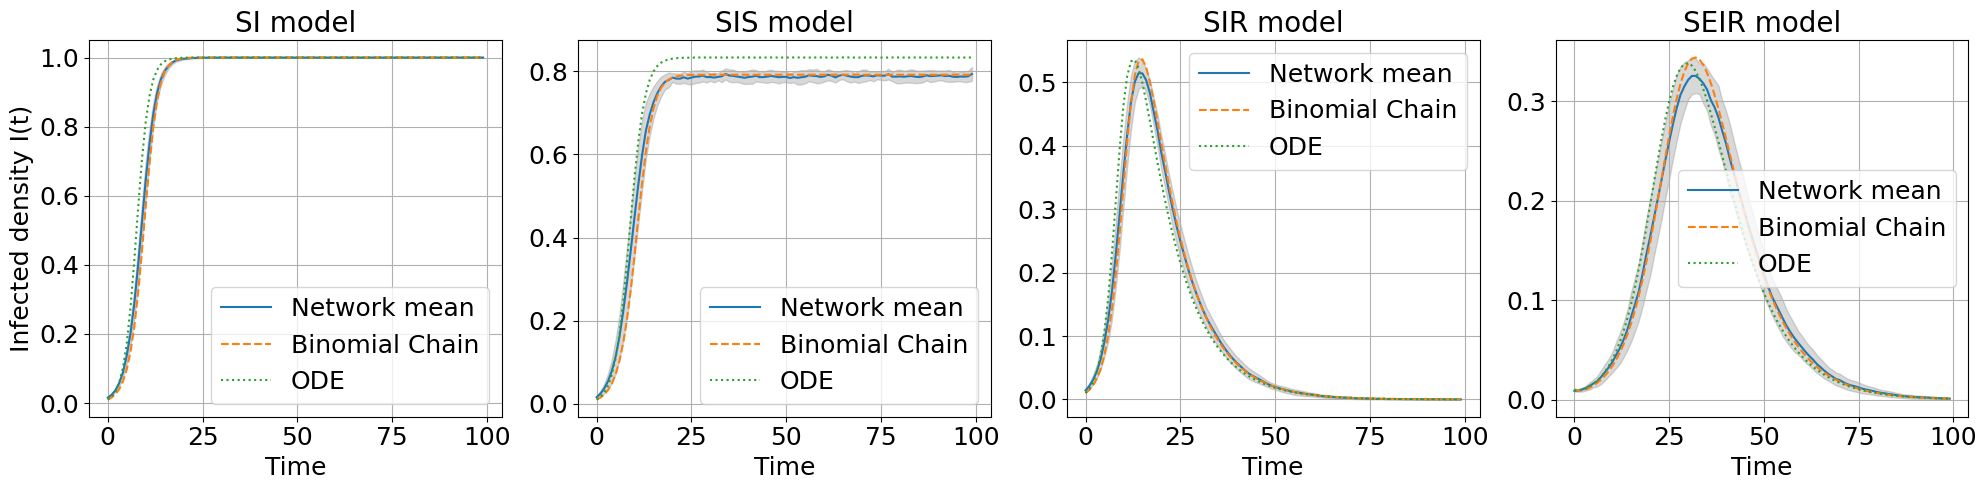

In [12]:
plot_infected_comparison(models, results_all_er, T, label_plot)

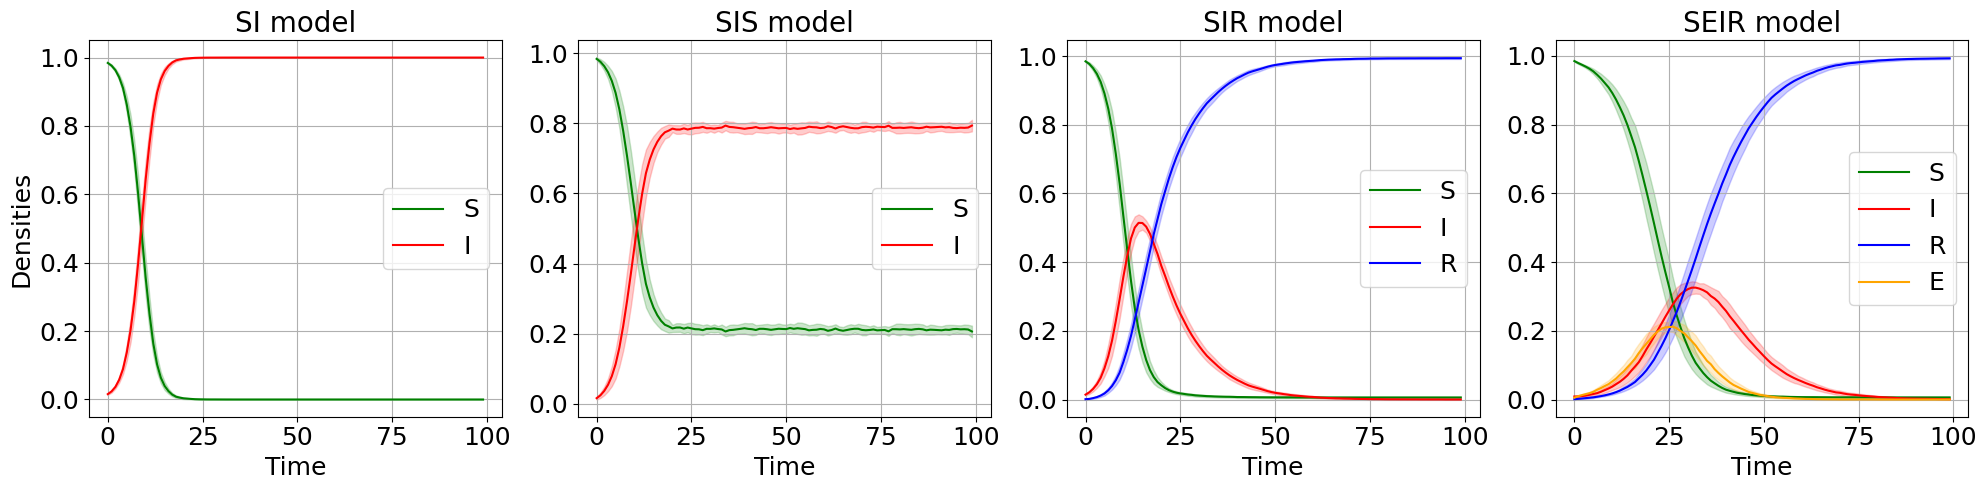

In [13]:
plot_species_all_models(models, results_all_er, T, label_plot)

### Heterogeneous case: Small world network

In [14]:
# Small world model
label_plot = 'small_world'
G_sw = nx.watts_strogatz_graph(N, k0, p_rewire)
k_avg = sum(dict(G_sw.degree()).values()) / N
print("Average degree:", k_avg)

models = ["SI", "SIS", "SIR", "SEIR"]

results_all_sw = {}
for model in models:
    results_all_sw[model] = simulate_epidemic_multiple(
        model=model, 
        G=G_sw, 
        beta=beta, 
        mu=mu, 
        sigma=sigma, 
        initial_infected=initial_infected, 
        k=k_avg, 
        T=T, 
        n_runs=n_runs) 

Average degree: 30.0


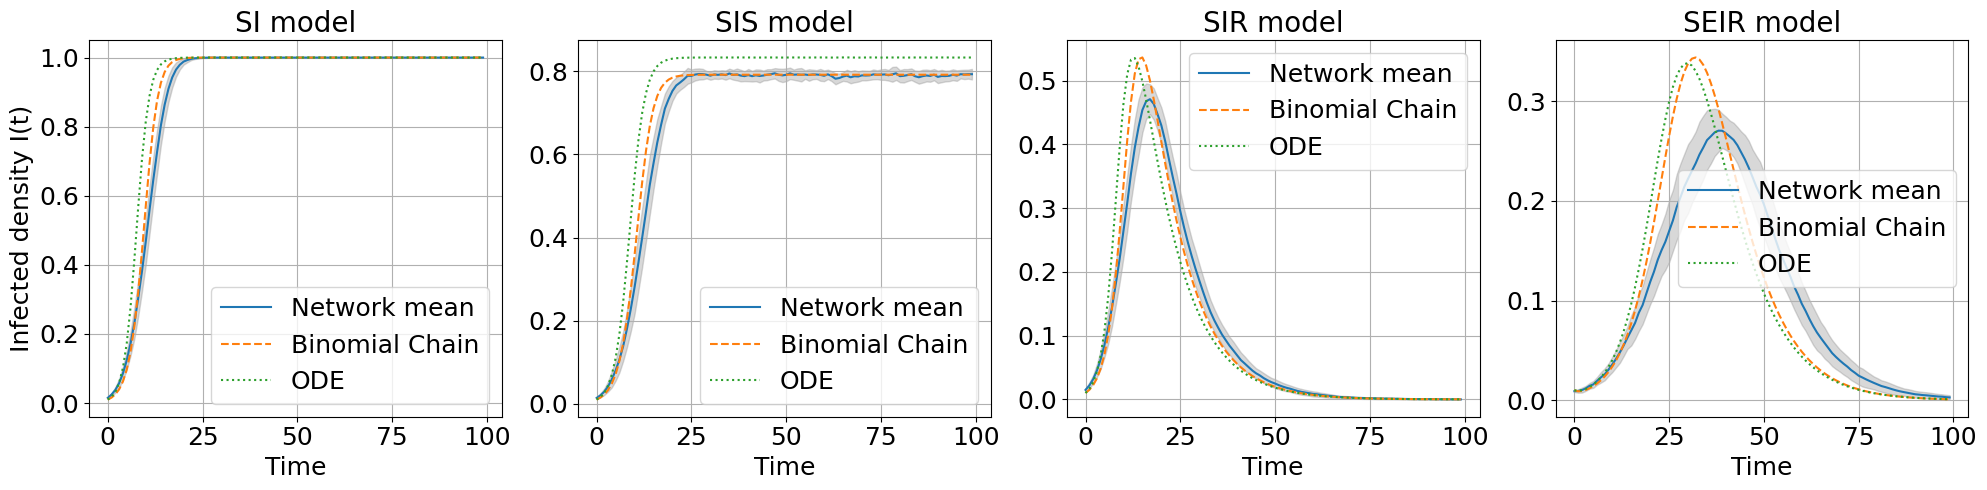

In [15]:
plot_infected_comparison(models, results_all_sw, T, label_plot)

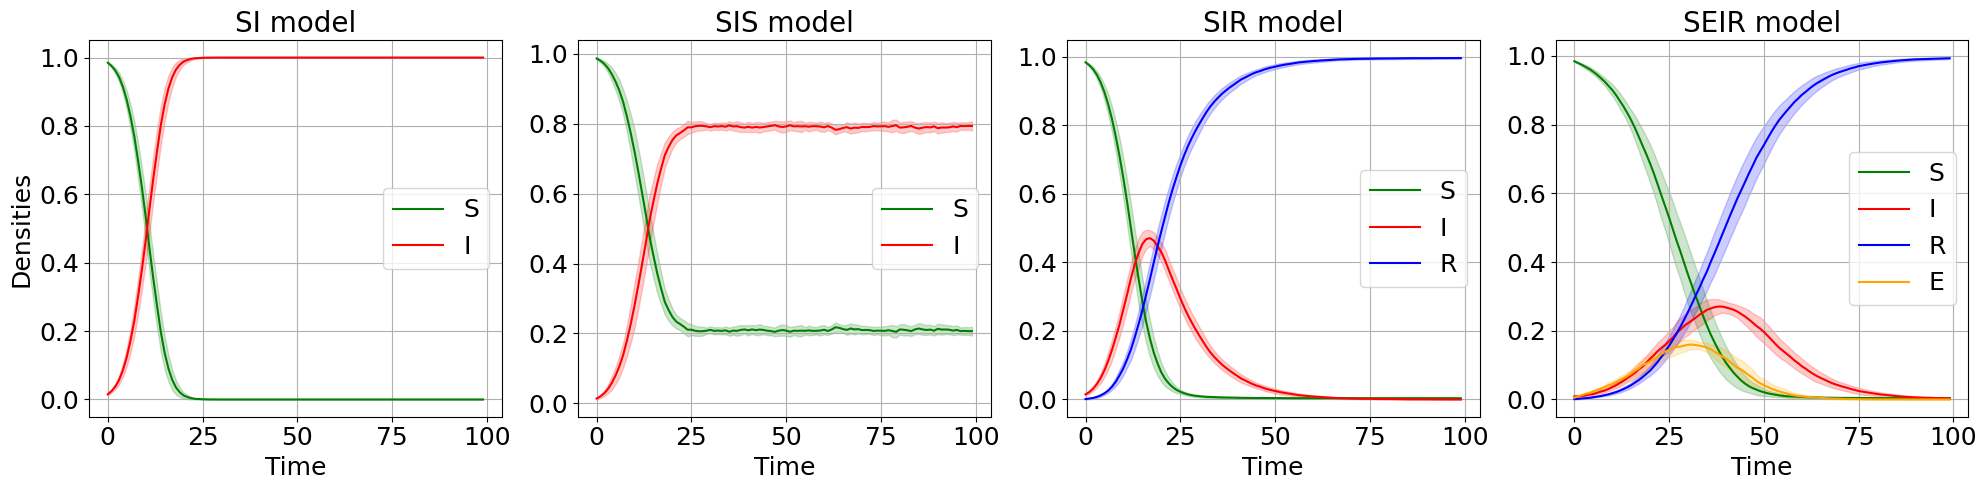

In [16]:
plot_species_all_models(models, results_all_sw, T, label_plot)

### Heterogeneous case: Barabási–Albert network

In [17]:
# Barabási–Albert model (scale-free network)
label_plot = 'scale_free'
G_sf = nx.barabasi_albert_graph(N, m)
# Average degree (≈ 2m)
k_avg = sum(dict(G_sf.degree()).values()) / N
print("Average degree:", k_avg)

models = ["SI", "SIS", "SIR", "SEIR"]

results_all_sf = {}
for model in models:
    results_all_sf[model] = simulate_epidemic_multiple(
        model=model,
        G=G_sf,
        beta=beta,
        mu=mu,
        sigma=sigma,
        initial_infected=initial_infected,
        k=k_avg,   
        T=T,
        n_runs=n_runs
    )

Average degree: 29.55


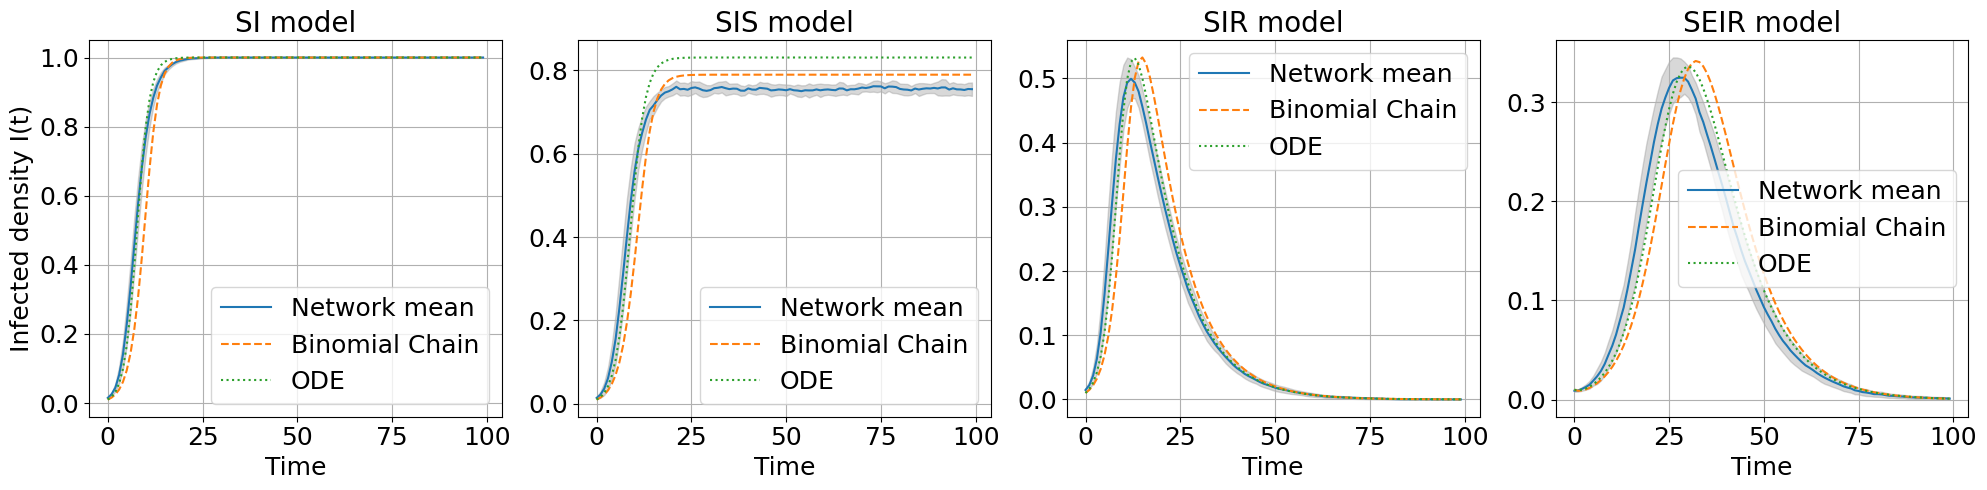

In [18]:
plot_infected_comparison(models, results_all_sf, T, label_plot)

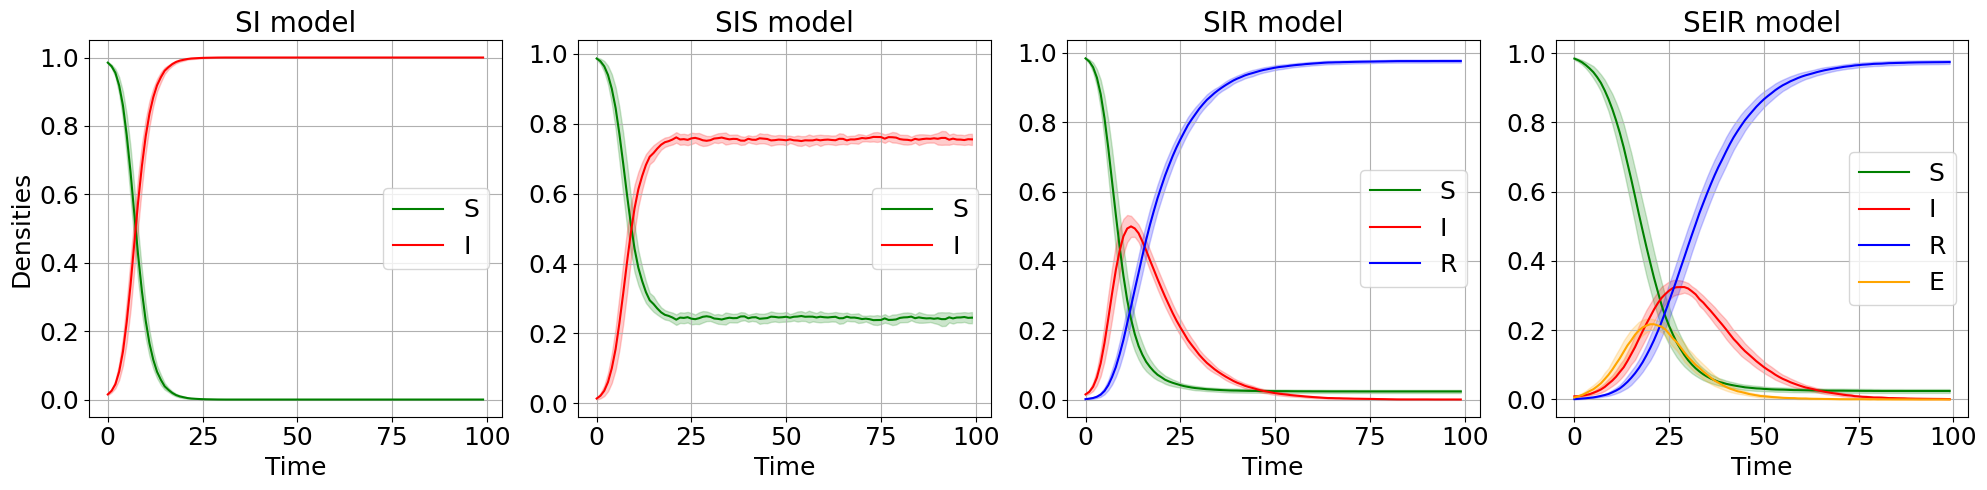

In [19]:
plot_species_all_models(models, results_all_sf, T, label_plot)

### Comparison Hom - Het

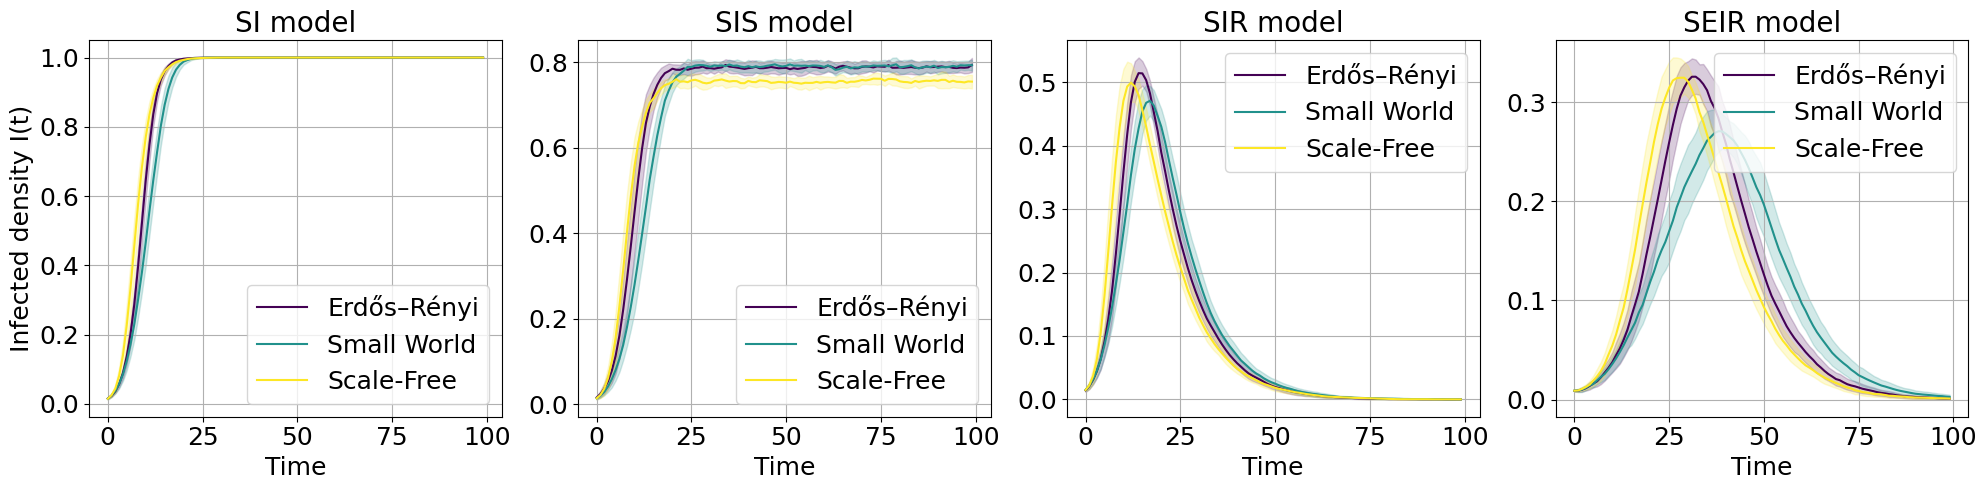

In [96]:
plot_infected_networks_comparison(
    models,
    results_all_er,
    results_all_sw,
    results_all_sf,
    T
)

## Epidemic threshold

In [29]:
def network_stats(G, mu, name="Network"):
    
    degrees = np.array([d for _, d in G.degree()])
    
    k_avg = np.mean(degrees)
    k2_avg = np.mean(degrees**2)
    
    # Epidemic threshold (HMF)
    beta_c = mu * k_avg / k2_avg
    
    print(f"--- {name} ---")
    print(f"<k>     = {k_avg:.4f}")
    print(f"<k^2>   = {k2_avg:.4f}")
    print(f"beta_c  = {beta_c:.6f}")
    print()
    
    return k_avg, k2_avg, beta_c

In [32]:
N = 1000               # number of nodes
T = 100                # timesteps 
mu = 0.2               # recovery rate 
sigma = 0.2
initial_infected = 1   
n_runs = 400

# Erdős–Rényi
p = 0.004               # <k> ≈ Np 

# Small-world
k0 = 4                
p_rewire = 0.2         # rewiring

# Scale-free (Barabási–Albert)
m = 2                 # <k> ≈ 2m

G_er = nx.erdos_renyi_graph(N, p)
G_sw = nx.watts_strogatz_graph(N, k0, p_rewire)
G_sf = nx.barabasi_albert_graph(N, m)

k_er, k2_er, bc_er = network_stats(G_er, mu, "Erdős–Rényi")
k_sw, k2_sw, bc_sw = network_stats(G_sw, mu, "Small-world")
k_sf, k2_sf, bc_sf = network_stats(G_sf, mu, "Scale-free (BA)")


--- Erdős–Rényi ---
<k>     = 4.0600
<k^2>   = 20.4400
beta_c  = 0.039726

--- Small-world ---
<k>     = 4.0000
<k^2>   = 16.7600
beta_c  = 0.047733

--- Scale-free (BA) ---
<k>     = 3.9920
<k^2>   = 39.9600
beta_c  = 0.019980



In [33]:
explored_beta = [0.00025, 0.0005, 0.00075, 0.001, 0.0025, 0.005, 0.0075,
                0.01, 0.011, 0.012, 0.013, 0.014, 0.015,
                0.0175, 0.02, 0.0225, 0.025, 0.0275, 0.03,
                0.0325, 0.035, 0.0375, 0.04,
                0.0425, 0.045, 0.0475, 0.05,
                0.0525, 0.055, 0.0575, 0.06,
                0.075, 0.1, 0.2, 0.3, 0.4]

AR_er = []
AR_er_std = []

AR_sw = []
AR_sw_std = []

AR_sf = []
AR_sf_std = []

for beta in explored_beta:
    
    print("beta =", beta)
    
    mean, std = final_attack_rate(G_er, beta, mu, sigma, model="SIR", n_runs=n_runs)
    AR_er.append(mean)
    AR_er_std.append(std)
    
    mean, std = final_attack_rate(G_sw, beta, mu, sigma, model="SIR", n_runs=n_runs)
    AR_sw.append(mean)
    AR_sw_std.append(std)
    
    mean, std = final_attack_rate(G_sf, beta, mu, sigma, model="SIR", n_runs=n_runs)
    AR_sf.append(mean)
    AR_sf_std.append(std)

beta = 0.00025
beta = 0.0005
beta = 0.00075
beta = 0.001
beta = 0.0025
beta = 0.005
beta = 0.0075
beta = 0.01
beta = 0.011
beta = 0.012
beta = 0.013
beta = 0.014
beta = 0.015
beta = 0.0175
beta = 0.02
beta = 0.0225
beta = 0.025
beta = 0.0275
beta = 0.03
beta = 0.0325
beta = 0.035
beta = 0.0375
beta = 0.04
beta = 0.0425
beta = 0.045
beta = 0.0475
beta = 0.05
beta = 0.0525
beta = 0.055
beta = 0.0575
beta = 0.06
beta = 0.075
beta = 0.1
beta = 0.2
beta = 0.3
beta = 0.4


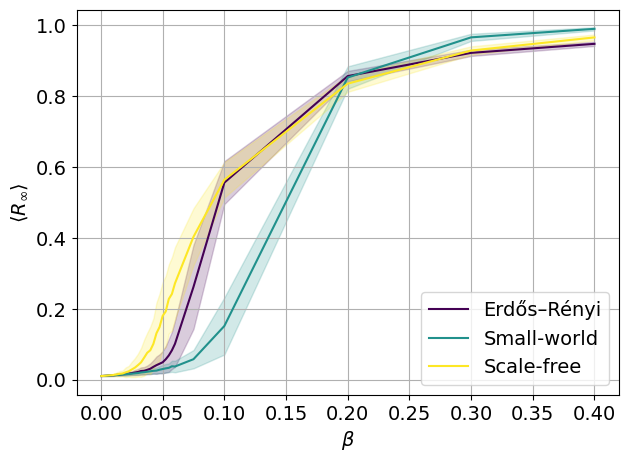

In [38]:
plt.figure(figsize=(7,5))

title_fs = 20
label_fs = 14
tick_fs = 14
legend_fs = 14

cmap = mpl.colormaps['viridis']
labels = ["Erdős–Rényi", "Small-world", "Scale-free"]
colors = [cmap(i) for i in np.linspace(0, 1, len(labels))]

# ER
plt.plot(explored_beta, AR_er, label=labels[0], color=colors[0])
plt.fill_between(explored_beta,
                 np.array(AR_er) - np.array(AR_er_std),
                 np.array(AR_er) + np.array(AR_er_std),
                 color=colors[0], alpha=0.2)

# SW
plt.plot(explored_beta, AR_sw, label=labels[1], color=colors[1])
plt.fill_between(explored_beta,
                 np.array(AR_sw) - np.array(AR_sw_std),
                 np.array(AR_sw) + np.array(AR_sw_std),
                 color=colors[1], alpha=0.2)

# SF
plt.plot(explored_beta, AR_sf, label=labels[2], color=colors[2])
plt.fill_between(explored_beta,
                 np.array(AR_sf) - np.array(AR_sf_std),
                 np.array(AR_sf) + np.array(AR_sf_std),
                 color=colors[2], alpha=0.2)

plt.xlabel(r"$\beta$", fontsize=label_fs)
plt.ylabel(r"$\langle R_\infty \rangle$", fontsize=label_fs)

plt.xticks(fontsize=tick_fs)
plt.yticks(fontsize=tick_fs)

plt.legend(fontsize=legend_fs, loc='lower right')
plt.grid()

plt.savefig("plots/epidemic_threshold.pdf", bbox_inches="tight")
plt.show()

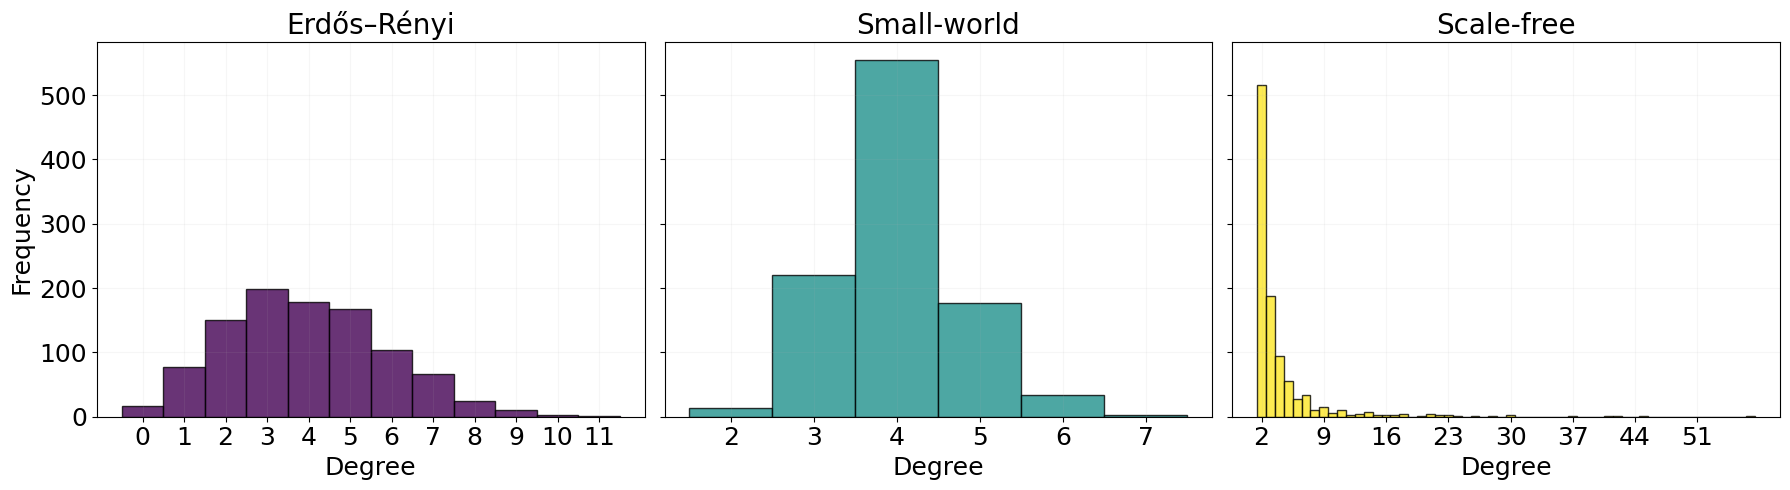

In [28]:
deg_er = [d for _, d in G_er.degree()]
deg_sw = [d for _, d in G_sw.degree()]
deg_sf = [d for _, d in G_sf.degree()]

cmap = mpl.colormaps['viridis']
labels = ["Erdős–Rényi", "Small-world", "Scale-free"]
colors = [cmap(i) for i in np.linspace(0, 1, len(labels))]

title_fs = 20
label_fs = 18
tick_fs = 18

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Erdős–Rényi
plot_hist(axes[0], deg_er, labels[0], colors[0])
axes[0].set_ylabel("Frequency", fontsize=label_fs)
axes[0].tick_params(axis='both', labelsize=tick_fs)
axes[0].grid(alpha=0.1)

# Small-world
plot_hist(axes[1], deg_sw, labels[1], colors[1])
axes[1].tick_params(axis='both', labelsize=tick_fs)
axes[1].grid(alpha=0.1)

# Scale-free
plot_hist(axes[2], deg_sf, labels[2], colors[2])
axes[2].tick_params(axis='both', labelsize=tick_fs)
axes[2].grid(alpha=0.1)

plt.tight_layout()
plt.savefig("plots/networks_degrees.pdf", bbox_inches="tight")
plt.show()

## Immunization

In [115]:
def random_vaccination(S_nodes, rate):
    n = int(rate * len(S_nodes))
    if n > 0:
        return set(random.sample(S_nodes, n))
    return set()

def acquaintance_vaccination(G, S_nodes, rate):
    n = int(rate * len(S_nodes))
    vaccinated = set()
    
    S_nodes = list(S_nodes)
    
    while len(vaccinated) < n and len(S_nodes) > 0:
        v = random.choice(S_nodes)
        neigh = list(G.neighbors(v))
        if neigh:
            vaccinated.add(random.choice(neigh))
    
    return vaccinated

In [116]:
def run_SIR(G, strategy, beta):
    
    state = {node: 'S' for node in G.nodes()}
    
    infected_init = random.sample(list(G.nodes()), initial_infected)
    for n in infected_init:
        state[n] = 'I'
    
    I_list = []
    
    t = 0
    while True:
        new_state = state.copy()
        
        S_nodes = [n for n in G.nodes() if state[n] == 'S']
        
        if strategy == 'random':
            vaccinated = random_vaccination(S_nodes, immunization_rate)
        else:
            vaccinated = acquaintance_vaccination(G, S_nodes, immunization_rate)
        
        for v in vaccinated:
            new_state[v] = 'R'
        
        # SIR dynamics
        for node in G.nodes():
            if state[node] == 'I':
                
                for neigh in G.neighbors(node):
                    if state[neigh] == 'S' and random.random() < beta:
                        new_state[neigh] = 'I'
                
                if random.random() < mu:
                    new_state[node] = 'R'
        
        state = new_state
        
        I = sum(1 for n in state if state[n] == 'I')
        I_list.append(I)
        
        t += 1
        
        if I == 0 or t >= T_max:
            break
    
    return I_list

In [117]:
N = 3000
m = 3
mu = 0.05
beta_list = [0.05, 0.1, 0.15]

initial_infected = 10
T_max = 1000
n_runs = 400

immunization_rate = 0.01  

G = nx.barabasi_albert_graph(N, m)

In [118]:
results = {}

for beta in beta_list:
    results[beta] = {'rand': [], 'acq': []}
    
    for _ in range(n_runs):
        
        I_r = run_SIR(G, 'random', beta)
        I_a = run_SIR(G, 'acq', beta)
        
        results[beta]['rand'].append(I_r)
        results[beta]['acq'].append(I_a)

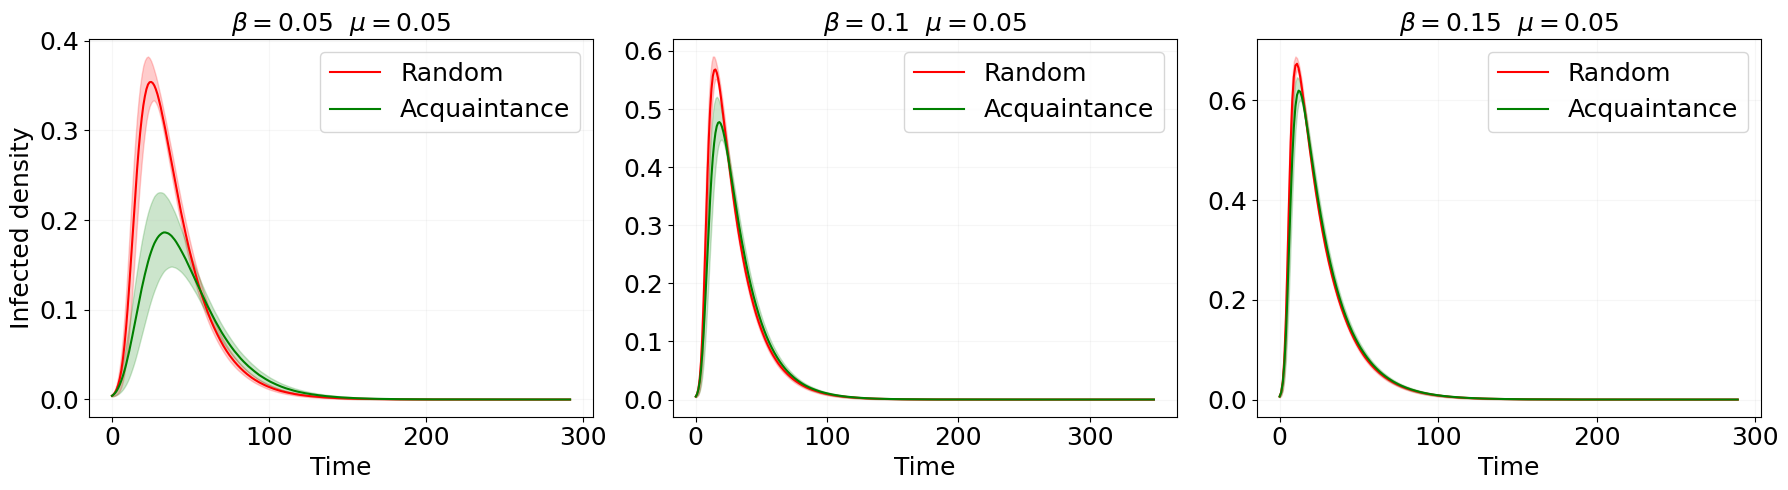

In [124]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

title_fs = 18
label_fs = 18
tick_fs = 18

for i, beta in enumerate(beta_list):
    
    ax = axes[i]
    
    max_len = max(
        max(len(x) for x in results[beta]['rand']),
        max(len(x) for x in results[beta]['acq'])
    )
    
    def to_array(list_curves):
        arr = np.zeros((n_runs, max_len))
        for j, c in enumerate(list_curves):
            arr[j, :len(c)] = c
            arr[j, len(c):] = c[-1]
        return arr
    
    rand_arr = to_array(results[beta]['rand']) / N
    acq_arr  = to_array(results[beta]['acq']) / N
    
    mean_r = rand_arr.mean(axis=0)
    std_r  = rand_arr.std(axis=0)
    
    mean_a = acq_arr.mean(axis=0)
    std_a  = acq_arr.std(axis=0)
    
    t = np.arange(max_len)
    
    ax.plot(t, mean_r, label='Random', color='red')
    ax.fill_between(t, mean_r-std_r, mean_r+std_r, color='red', alpha=0.2)
    
    ax.plot(t, mean_a, label='Acquaintance', color='green')
    ax.fill_between(t, mean_a-std_a, mean_a+std_a, color='green', alpha=0.2)
    
    ax.set_title(f"$\\beta = {beta}$  $\\mu = {mu}$", fontsize=title_fs)
    ax.set_xlabel("Time", fontsize=label_fs)
    
    if i == 0:
        ax.set_ylabel("Infected density", fontsize=label_fs)
    
    ax.tick_params(axis='both', labelsize=tick_fs)
    ax.grid(alpha=0.1)
    ax.legend(fontsize=label_fs)

plt.tight_layout()
plt.savefig("plots/immunization.pdf", bbox_inches="tight")
plt.show()